# 02 - Randomized Experiments and Stats Review
 
 
## Brute Force Independence with Randomization


## An A/B Testing Example
 

In [3]:
import pandas as pd # for data manipulation
pd.set_option('display.max_rows', 10)


**Context:** Cross-sell e-mail sent to customers. You selected 3 random samples from customer base:
* No e-mail
* Long e-mail about premium subscription
* Short e-mail about premium subscription


In [4]:
import numpy as np # for numerical computation

data = pd.read_csv("./data/cross_sell_email.csv")
data.head(5)

,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
2,1,long,17,0
3,1,long,34,0
4,1,no_email,14,0


In [5]:
## Quick data inspection
data.info()



<class 'pandas.DataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            323 non-null    int64
 1   cross_sell_email  323 non-null    str  
 2   age               323 non-null    int64
 3   conversion        323 non-null    int64
dtypes: int64(3), str(1)
memory usage: 10.2 KB


In [6]:
data.describe()

,gender,age,conversion
count,323.000000,323.000000,323.000000
mean,0.578947,21.102167,0.077399
std,0.494494,5.777884,0.267639
min,0.000000,14.000000,0.000000
25%,0.000000,17.000000,0.000000
50%,1.000000,20.000000,0.000000
75%,1.000000,24.000000,0.000000
max,1.000000,44.000000,1.000000


Average conversion rate for each of the treatment groups

In [7]:
(data
 .groupby(["cross_sell_email"])
 .mean())


,gender,age,conversion
cross_sell_email,,,
long,0.550459,21.752294,0.055046
no_email,0.542553,20.489362,0.042553
short,0.633333,20.991667,0.125000


To evaluate balance, we can check the normalized differences between treatment groups:

$\mu$ = sample mean
$\sigma^2$ = sample variance



In [8]:
X = ["gender", "age"] # covariates

mu = data.groupby("cross_sell_email")[X].mean()
var = data.groupby("cross_sell_email")[X].var()

norm_diff = ((mu - mu.loc["no_email"])/
             np.sqrt((var + var.loc["no_email"])/2))

norm_diff

,gender,age
cross_sell_email,,
long,0.015802,0.221423
no_email,0.000000,0.000000
short,0.184341,0.087370


 
## Stats review


Standard error of the mean 

In [10]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
from cycler import cycler
import matplotlib

palette = {
    "Bottom 1%": "#e34948",  # red — one pole
    "Middle":    "#c3c2b7",  # neutral gray — not an extreme
    "Top 1%":    "#2a78d6",  # blue — other pole
}

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

#plt.rc('axes', prop_cycle=default_cycler)

matplotlib.rcParams.update({'font.size': 18})

### Education data

ENEM scores (Brazilian standardized high school scores, similar to SATs) over a 3 year period. 

In [11]:
df = pd.read_csv("data/enem_scores.csv")
df.sort_values(by="avg_score", ascending=False).head(10)

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
16668,2005,33062633,59,81.89
16794,2005,33065403,177,81.66
10043,2007,29342880,43,80.32
18121,2007,33152314,14,79.82
16781,2007,33065250,80,79.67
3026,2007,22025740,144,79.52
14636,2007,31311723,222,79.41
17318,2007,33087679,210,79.38


In [12]:
df.describe()

,year,school_id,number_of_students,avg_score
count,37941.000000,3.794100e+04,37941.000000,37941.000000
mean,2006.000000,3.356336e+07,139.524024,46.801205
std,0.816507,8.738978e+06,122.039531,8.560705
min,2005.000000,1.100006e+07,8.000000,16.010000
25%,2005.000000,2.921849e+07,59.000000,40.750000
50%,2006.000000,3.500546e+07,105.000000,45.080000
75%,2007.000000,3.592157e+07,181.000000,51.210000
max,2007.000000,5.301411e+07,1636.000000,82.970000


Text(0.5, 1.0, 'Number of Students of 1% Top Schools (Right)')

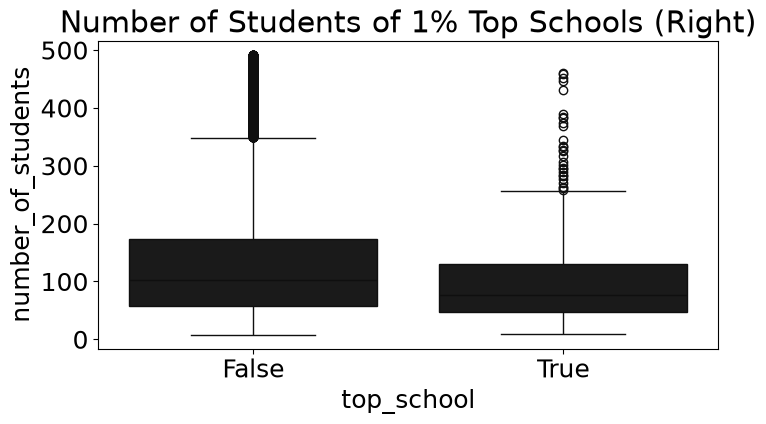

In [ ]:
plot_data = (df
             .assign(top_school = df["avg_score"] >= np.quantile(df["avg_score"], .99))
             [["top_school", "number_of_students"]]
             .query(f"number_of_students<{np.quantile(df['number_of_students'], .98)}")) # remove outliers

plt.figure(figsize=(8,4))
ax = sns.boxplot(x="top_school", y="number_of_students", data=plot_data)

plt.title("Number of Students of 1% Top Schools (Right)")


Top 1% of schools have on average fewer students. However, it turns out that the bottom 1% of schools also has very few students. 

As the number of students grows, the average score becomes more and more precise. Schools with very few students (low sample size) can have very high and low scores simply due to chance. 


Text(0.5, 1.0, 'Number of Students of 1% Bottom Schools (Right)')

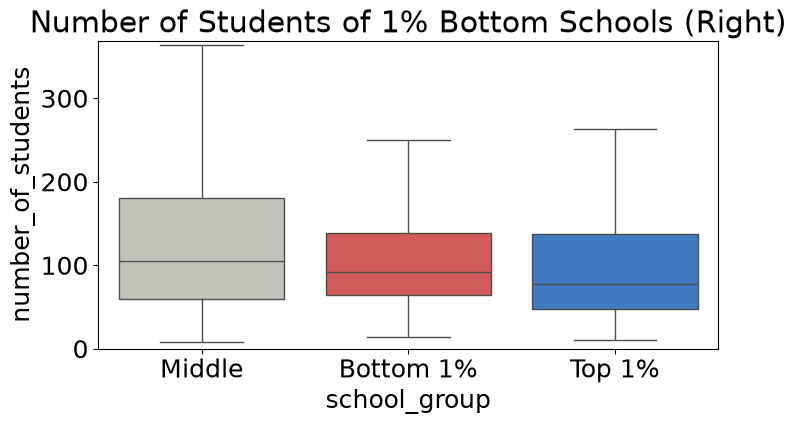

In [ ]:
q_99 = np.quantile(df["avg_score"], .99)
q_01 = np.quantile(df["avg_score"], .01)

plot_data = df.assign(
    school_group=np.select(
        condlist=[df["avg_score"] >= q_99, df["avg_score"] <= q_01],
        choicelist=["Top 1%", "Bottom 1%"],
        default="Middle"
    )
)

plt.figure(figsize=(8,4))
ax = sns.boxplot(x="school_group", y="number_of_students", data=plot_data, 
                 palette=palette,
                showfliers=False #remove outliers
                ) 
ax.set_ylim(0, plot_data["number_of_students"].quantile(0.95)),

plt.title("Number of Students of 1% Bottom Schools (Right)")


Text(0.5, 1.0, 'ENEM Score by Number of Students in the School')

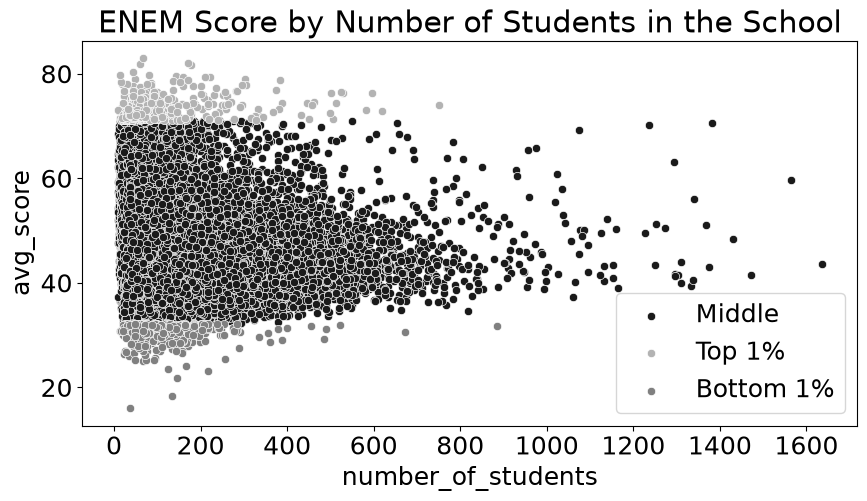

In [ ]:
# Scatter plot 

plt.figure(figsize=(10,5))
sns.scatterplot(y="avg_score", x="number_of_students", data=plot_data.query("school_group=='Middle'"), label="Middle", palette=palette)
ax = sns.scatterplot(y="avg_score", x="number_of_students", data=plot_data.query("school_group=='Top 1%'"), color="0.7", label="Top 1%", palette=palette)
ax = sns.scatterplot(y="avg_score", x="number_of_students", data=plot_data.query("school_group=='Bottom 1%'"), color="0.5", label="Bottom 1%", palette=palette)

plt.title("ENEM Score by Number of Students in the School")


##  The Standard Error of Our Estimates
 

In [13]:
data = pd.read_csv("./data/cross_sell_email.csv")

short_email = data.query("cross_sell_email=='short'")["conversion"]
long_email = data.query("cross_sell_email=='long'")["conversion"]
email = data.query("cross_sell_email!='no_email'")["conversion"]
no_email = data.query("cross_sell_email=='no_email'")["conversion"]

data.groupby("cross_sell_email").size()

cross_sell_email
long        109
no_email     94
short       120
dtype: int64

In [14]:
data.cross_sell_email.value_counts()
#data.groupby("cross_sell_email").size()

cross_sell_email
short       120
long        109
no_email     94
Name: count, dtype: int64

In [15]:
## Define function that computes standard error of the mean
# 
def se(y: pd.Series):
    return y.std() / np.sqrt(len(y))

print("SE for Long Email:", se(long_email))
print("SE for Short Email:", se(short_email))

SE for Long Email: 0.021946024609185506
SE for Short Email: 0.030316953129541618


In [16]:
# Alternatively, we can use the pandas built-in method for standard error of the mean (sem):
 
print("SE for Long Email:", long_email.sem())
print("SE for Short Email:", short_email.sem())

SE for Long Email: 0.021946024609185506
SE for Short Email: 0.030316953129541618


## Confidence Intervals
 

In frequentist statistics, our data is a manifestation of an underlying data-generating process, which is abstract and ideal. This process is governed by true parameters that are unchanging but also *unknown* to us.


*Example:*

* Suppose true conversion rate is 0.08, this is a Bernoulli distribution with p=0.08. 
* We'll run 10K experiments of size 100 and collect the average conversion

In [17]:

n = 100
conv_rate = 0.08

def run_experiment(): 
    return np.random.binomial(1, conv_rate, size=n) # n independent Bernoulli trials with probability of success conv_rate

np.random.seed(42)

experiments = [run_experiment().mean() for _ in range(10000)]

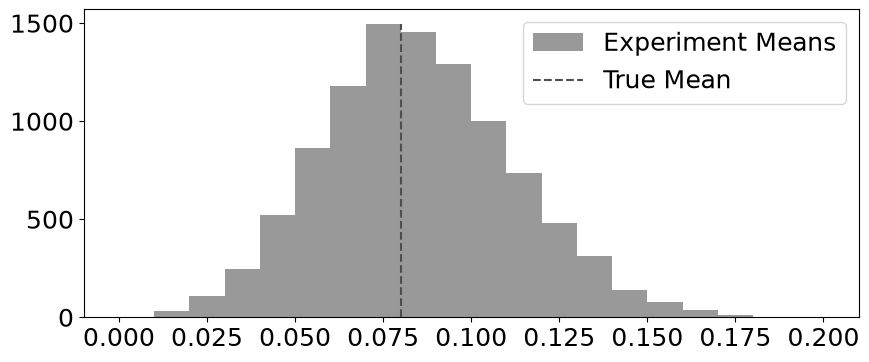

In [18]:
plt.figure(figsize=(10,4))
freq, bins, img = plt.hist(experiments, bins=20, label="Experiment Means", color="0.6")
plt.vlines(conv_rate, ymin=0, ymax=freq.max(), linestyles="dashed", label="True Mean", color="0.3")
plt.legend()


### Central Limit Theorem

(array([92.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  8.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

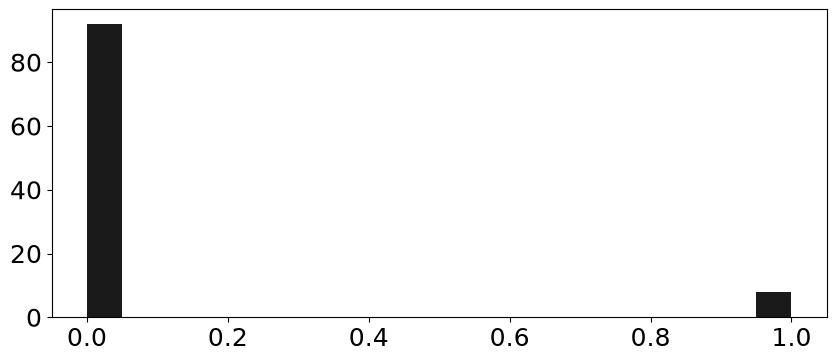

In [104]:
# Bernoulli distribution with n=1 and p=0.08 (100 samples)
np.random.seed(42)
plt.figure(figsize=(10,4))
plt.hist(np.random.binomial(1, 0.08, 100), bins=20)


95% of the mass of a normal distribution falls between ~2 (1.96) standard deviations above and below the mean

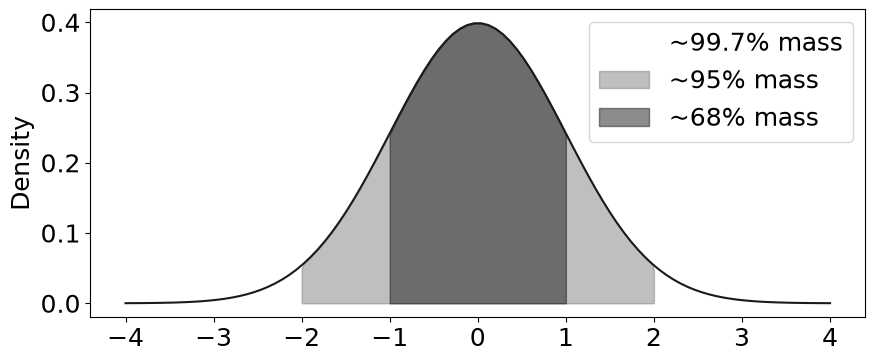

In [107]:
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10,4))
plt.plot(x, y, linestyle="solid")
plt.fill_between(x.clip(-3, +3), 0, y, alpha=0.5, label="~99.7% mass", color="C2")
plt.fill_between(x.clip(-2, +2), 0, y, alpha=0.5, label="~95% mass", color="C1")
plt.fill_between(x.clip(-1, +1), 0, y, alpha=0.5, label="~68% mass", color="C0")
plt.ylabel("Density")
plt.legend()


If you multiply the standard error by 2 and add and substract it from the mean of the experiments, you can construct a 95% confidence interval for the true mean.

In [108]:
exp_se = short_email.sem()
exp_mu = short_email.mean()
ci = (exp_mu - 2 * exp_se, exp_mu + 2 * exp_se)
print("95% CI for Short Email: ", ci)

95% CI for Short Email:  (np.float64(0.06436609374091676), np.float64(0.18563390625908324))


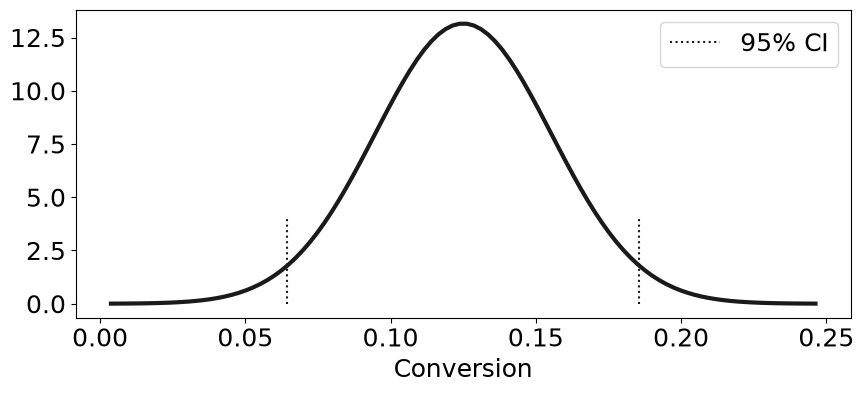

In [109]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=3)
plt.vlines(ci[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci[0], ymin=0, ymax=4, ls="dotted", label="95% CI")
plt.xlabel("Conversion")
plt.legend()


For any significance level $\alpha$, the factor needed to multiply the SE by in order to get a $1-\alpha$ confidence interval is given by the inverse CDF($\alpha/2$)


In [114]:
from scipy import stats

z = np.abs(stats.norm.ppf((1-.99)/2))
print(f"at 0.01 significance level, z = {z:.3f}")
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci

z = np.abs(stats.norm.ppf((1-.90)/2))
print(f"at 0.10 significance level, z = {z:.3f}")
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci

at 0.01 significance level, z = 2.576
at 0.10 significance level, z = 1.645


(np.float64(0.07513304968675566), np.float64(0.17486695031324434))

In [120]:
stats.norm.ppf((1-.99)/2) ## Left tail critical value for 99% confidence interval

np.float64(-2.5758293035489004)

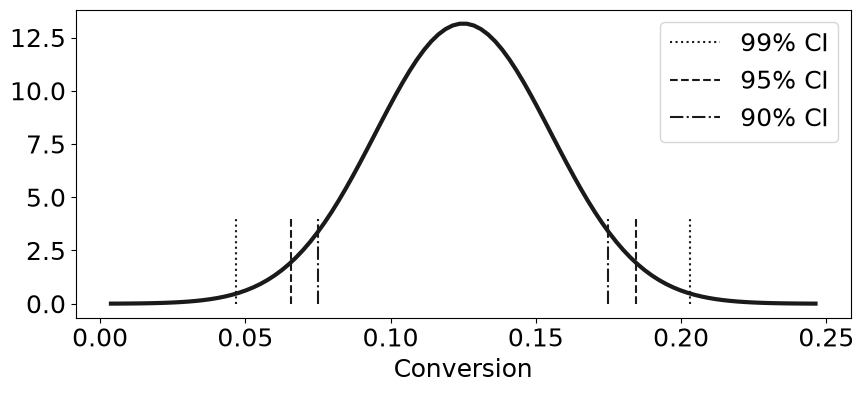

In [124]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)

ci_99 = (exp_mu - 2.576 * exp_se, exp_mu + 2.576 * exp_se)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=3)
plt.vlines(ci_99[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci_99[0], ymin=0, ymax=4, ls="dotted", label="99% CI")


ci_95 = (exp_mu - 1.96 * exp_se, exp_mu + 1.96 * exp_se)

plt.vlines(ci_95[1], ymin=0, ymax=4, ls="dashed")
plt.vlines(ci_95[0], ymin=0, ymax=4, ls="dashed", label="95% CI")
plt.xlabel("Conversion")
plt.legend()

ci_90 = (exp_mu - 1.645 * exp_se, exp_mu + 1.645 * exp_se)

plt.vlines(ci_90[1], ymin=0, ymax=4, ls="dashdot")
plt.vlines(ci_90[0], ymin=0, ymax=4, ls="dashdot", label="90% CI")
plt.xlabel("Conversion")
plt.legend()


In [125]:
def ci(y: pd.Series):
    return (y.mean() - 2 * y.sem(), y.mean() + 2 * y.sem())

print("95% CI for Short Email:", ci(short_email))
print("95% CI for Long Email:", ci(long_email))
print("95% CI for No Email:", ci(no_email))

95% CI for Short Email: (np.float64(0.06436609374091676), np.float64(0.18563390625908324))
95% CI for Long Email: (np.float64(0.01115382234126202), np.float64(0.09893792077800403))
95% CI for No Email: (np.float64(0.0006919679286838468), np.float64(0.08441441505003955))


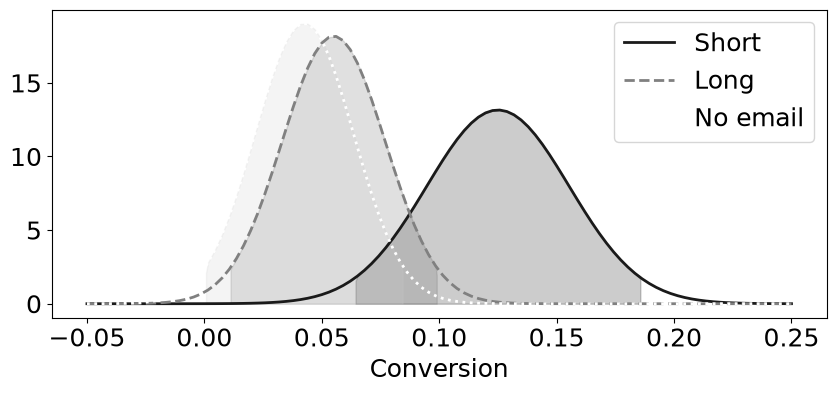

In [126]:
plt.figure(figsize=(10,4))

x = np.linspace(-0.05, .25, 100)
short_dist = stats.norm.pdf(x, short_email.mean(), short_email.sem())
plt.plot(x, short_dist, lw=2, label="Short", linestyle=linestyle[0])
plt.fill_between(x.clip(ci(short_email)[0], ci(short_email)[1]), 0, short_dist, alpha=0.2, color="0.0")

long_dist = stats.norm.pdf(x, long_email.mean(), long_email.sem())
plt.plot(x, long_dist, lw=2, label="Long", linestyle=linestyle[1])
plt.fill_between(x.clip(ci(long_email)[0], ci(long_email)[1]), 0, long_dist, alpha=0.2, color="0.4")

no_email_dist = stats.norm.pdf(x, no_email.mean(), no_email.sem())
plt.plot(x, no_email_dist, lw=2, label="No email", linestyle=linestyle[2])
plt.fill_between(x.clip(ci(no_email)[0], ci(no_email)[1]), 0, no_email_dist, alpha=0.2, color="0.8")

plt.xlabel("Conversion")
plt.legend()


## Hypothesis Testing
 

Sum or difference of two independent normal distribution is also a normal distribution.
* Mean = sum or difference of means
* Variance: sum of the variances

Simulated

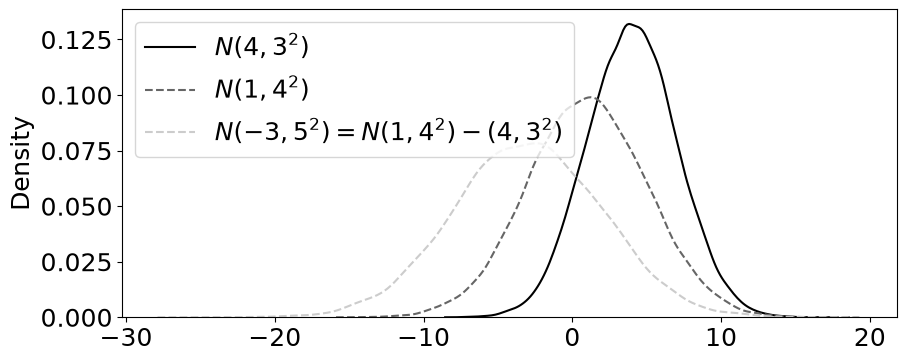

In [29]:
import seaborn as sns
from matplotlib import pyplot as plt

np.random.seed(123)

n1 = np.random.normal(4, 3, 30000)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1

plt.figure(figsize=(10,4))
sns.distplot(n1, hist=False, label="$N(4,3^2)$", color="0.0", kde_kws={"linestyle":linestyle[0]})
sns.distplot(n2, hist=False, label="$N(1,4^2)$", color="0.4", kde_kws={"linestyle":linestyle[1]})
sns.distplot(n_diff, hist=False,
             label=f"$N(-3, 5^2) = N(1,4^2) - (4,3^2)$", color="0.8", kde_kws={"linestyle":linestyle[1]})
plt.legend();

If you take the estimated distribution of two groups (ie. short email and no emial group), and subract one from the other, you get the distribution of the difference. With this distribution you can easily construct a 95% confidence interval for the difference in means:

In [30]:
diff_mu = short_email.mean() - no_email.mean()
diff_se = np.sqrt(no_email.sem()**2 + short_email.sem()**2)

ci = (diff_mu - 1.96*diff_se, diff_mu + 1.96*diff_se)
print(f"95% CI for the differece (short email - no email):\n{ci}")

95% CI for the differece (short email - no email):
(np.float64(0.01023980847439844), np.float64(0.15465380854687816))


CI doens't contain 0, so we can reject the null hypothesis with 95% confidence that the two groups have the same mean conversion rate.

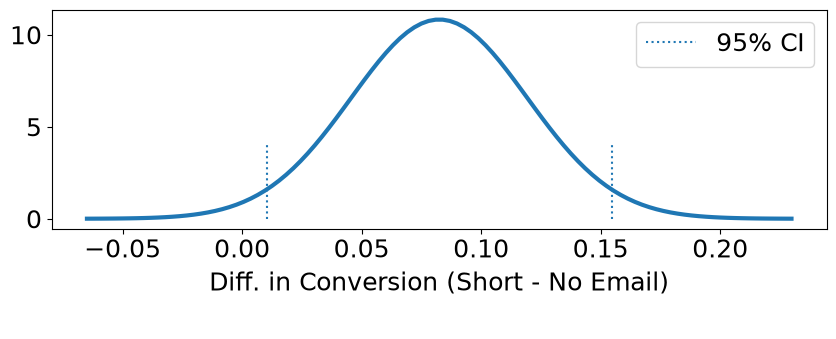

In [31]:
x = np.linspace(diff_mu - 4*diff_se, diff_mu + 4*diff_se, 100)
y = stats.norm.pdf(x, diff_mu, diff_se)

plt.figure(figsize=(10,3))
plt.plot(x, y, lw=3)
plt.vlines(ci[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci[0], ymin=0, ymax=4, ls="dotted", label="95% CI")
plt.xlabel("Diff. in Conversion (Short - No Email)\n")
plt.legend()
plt.subplots_adjust(bottom=0.15)





### Null Hypothesis


Example:

$H_o:$ The difference in conversion rate is 1%

In [32]:
# shifting the CI
diff_mu_shifted =  short_email.mean() - no_email.mean() - 0.01 
diff_se = np.sqrt(no_email.sem()**2 + short_email.sem()**2)

ci = (diff_mu_shifted - 1.96*diff_se, diff_mu_shifted + 1.96*diff_se)
print(f"95% CI 1% difference between (short email - no email):\n{ci}")

95% CI 1% difference between (short email - no email):
(np.float64(0.00023980847439844521), np.float64(0.14465380854687815))



### Test Statistic


Since $t_\delta$ is centered around zero under $H_0$, values abvoe or below 1.96 would be extremely unlikely

In [34]:
t_stat = (diff_mu - 0) / diff_se
t_stat

np.float64(2.2379512318715364)


 
## P-values


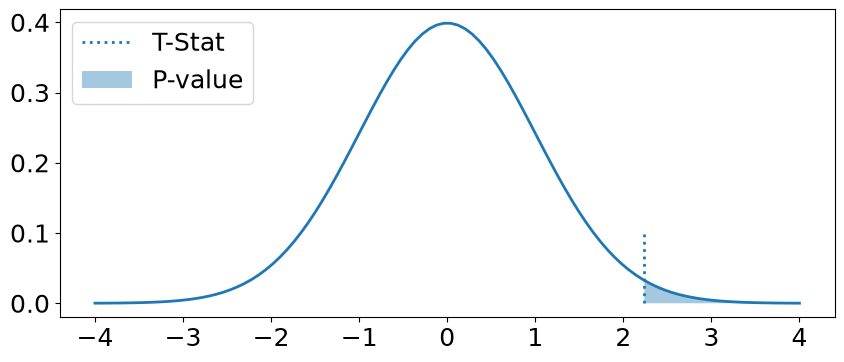

In [35]:
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=2)
plt.vlines(t_stat, ymin=0, ymax=0.1, ls="dotted", label="T-Stat", lw=2)
plt.fill_between(x.clip(t_stat), 0, y, alpha=0.4, label="P-value")
plt.legend()

To get the p-value you need to compute the area under the standard normal distribution before the t-statistic for a one-sided null hypotheseis, and multiply the result by 2 for a two-sided null hypothesis.

In [37]:
print("P-value:", (1 - stats.norm.cdf(t_stat))*2) # this one is 2 sided

P-value: 0.025224235562152142


## Power


Text(0.5, 1.0, 'Power = area of the TRUE sampling distribution past the significance threshold')

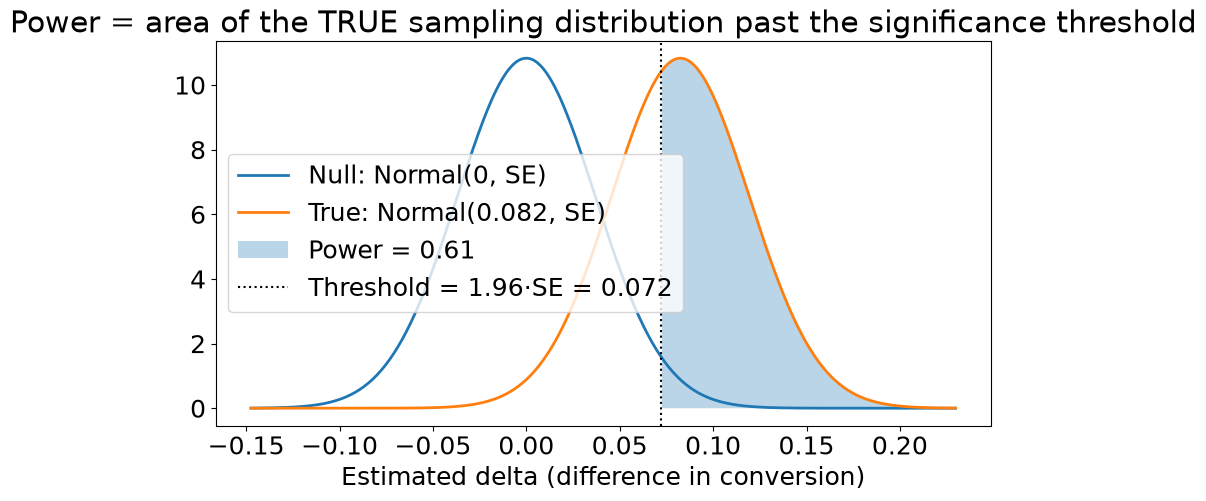

In [39]:
short_email = data.query("cross_sell_email=='short'")["conversion"]
no_email = data.query("cross_sell_email=='no_email'")["conversion"]

delta = short_email.mean() - no_email.mean()      # observed effect, treated as "true" effect here
se_diff = np.sqrt(short_email.sem()**2 + no_email.sem()**2)
threshold = 1.96 * se_diff                        # significance bar, derived from the null curve

x = np.linspace(-4*se_diff, delta + 4*se_diff, 500)
null_curve = stats.norm.pdf(x, loc=0, scale=se_diff)       # curve 1: Normal(0, SE)
true_curve = stats.norm.pdf(x, loc=delta, scale=se_diff)   # curve 2: Normal(delta, SE)

power = 1 - stats.norm.cdf(threshold, loc=delta, scale=se_diff)

plt.figure(figsize=(10, 5))
plt.plot(x, null_curve, label="Null: Normal(0, SE)", lw=2)
plt.plot(x, true_curve, label=f"True: Normal({delta:.3f}, SE)", lw=2)

# shade power: area under the TRUE curve past the threshold
x_power = x[x >= threshold]
plt.fill_between(x_power, stats.norm.pdf(x_power, loc=delta, scale=se_diff),
                  alpha=0.3, label=f"Power = {power:.2f}")

plt.axvline(threshold, ls="dotted", color="black", label=f"Threshold = 1.96·SE = {threshold:.3f}")
plt.xlabel("Estimated delta (difference in conversion)")
plt.legend()
plt.title("Power = area of the TRUE sampling distribution past the significance threshold")


In [38]:
stats.norm.cdf(0.84)

np.float64(0.7995458067395503)

## Sample Size Calculation


In [41]:
# in the book it is np.ceil(16 * no_email.std()**2/0.01), but it is missing the **2 in the denominator.
np.ceil(16 * (no_email.std()/0.08)**2)

np.float64(103.0)

In [42]:
data.groupby("cross_sell_email").size()

cross_sell_email
long        109
no_email     94
short       120
dtype: int64